<h1>IVAN RAYMOND M. AGUIWAS</h1>
<h4>BSIT-3C</h4>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
dengue = pd.read_csv("dengue.csv")

In [3]:
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


<h1>For each region, what is the month with the highest dengue cases?</h1>

In [4]:
peak_months = dengue.loc[
    dengue.groupby('Region')['Dengue_Cases'].idxmax(),
    ['Region', 'Month', 'Year', 'Dengue_Cases']
].reset_index(drop=True)

In [5]:
peak_months

,Region,Month,Year,Dengue_Cases
0,BARMM,August,2019,811
1,CAR,July,2016,2769
2,NCR,September,2019,11033
3,Region I,September,2019,4814
4,Region II,September,2018,3698
5,Region III,September,2019,9713
6,Region IV-A,September,2019,21658
7,Region IV-B,August,2019,2125
8,Region IX,July,2019,7024
9,Region V,September,2019,2846


<h1>INSIGHT 1</h1>

Significant regional outbreaks occurred in 2019, with Regions IV-A, VI, and NCR showing the highest dengue case counts—each recording several thousand cases and indicating concentrated hotspots during that year.

<hr>

<h1>INSIGHT 2</h1>

Most spikes align with rainy months (July–September), suggesting a strong seasonal pattern where increased rainfall likely enhances mosquito breeding, driving higher transmission rates across multiple regions.

<hr>

<h1>What are the long-term seasonal patterns of dengue cases across all regions, and which months consistently show peak outbreaks? code in jupyter</h1>

In [6]:
monthly_avg = dengue.groupby('Month')['Dengue_Cases'].mean().reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

In [7]:
monthly_avg

Month
January       992.094118
February      915.305882
March         677.364706
April         382.447059
May           381.023529
June          683.647059
July         1626.376471
August       2206.517647
September    2093.447059
October      1384.058824
November     1116.470588
December     1040.364706
Name: Dengue_Cases, dtype: float64

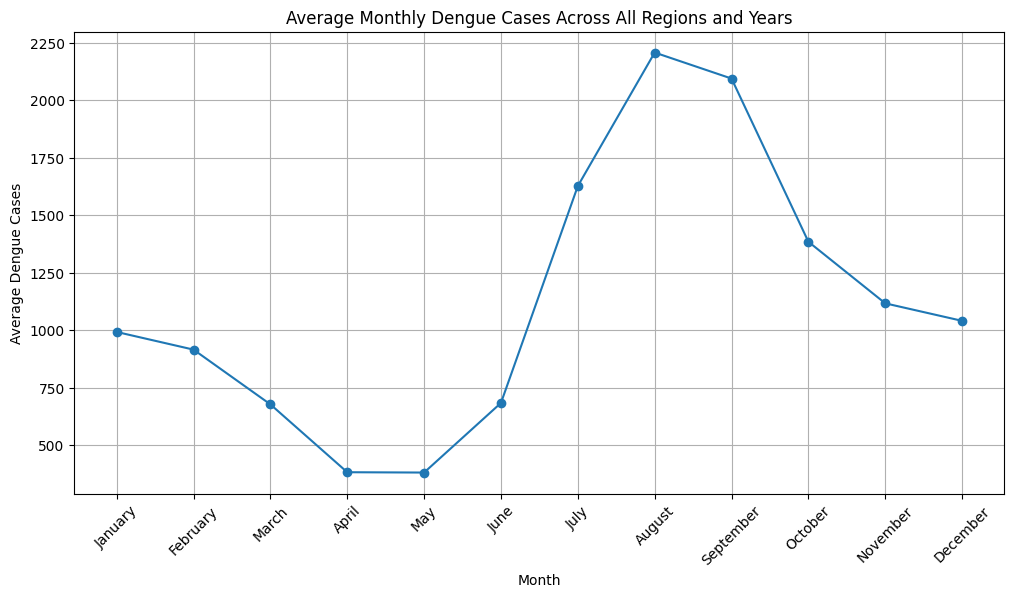

In [8]:
plt.figure(figsize=(12,6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Average Monthly Dengue Cases Across All Regions and Years")
plt.xlabel("Month")
plt.ylabel("Average Dengue Cases")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


<h1>INSIGHT 3</h1>

Dengue cases peak sharply during the rainy season, with August and September showing the highest averages—over 2,000 cases—indicating that transmission intensifies mid-year when mosquito breeding conditions are most favorable.

<hr>

<h1>INSIGHT 4</h1>

Cases drop significantly during the dry months, particularly from March to May, where averages fall below 400–700 cases, highlighting a clear seasonal pattern that can guide timing for preventive interventions.

<hr>

<H1>Identify the top 5 months (across years and regions) with the highest dengue cases.</H1>

In [9]:
dengue['Year_Month'] = dengue['Year'].astype(str) + '-' + dengue['Month'].astype(str).str.zfill(2)

# Group by Year-Month across all regions and sum dengue cases
monthly_totals = (
    dengue.groupby('Year_Month')['Dengue_Cases']
    .sum()
    .sort_values(ascending=False)
)

# Display the top 5 months
top_5_months = monthly_totals.head(5)
print("Top 5 months with the highest dengue cases:")
print(top_5_months)

Top 5 months with the highest dengue cases:
Year_Month
2019-September    89642
2019-August       85038
2019-July         55220
2019-October      46382
2018-September    38617
Name: Dengue_Cases, dtype: int64


<h1>INSIGHT 5</h1>

The year 2019 experienced the most severe dengue surge, with four of the five highest monthly case totals occurring that year—particularly in August and September, each surpassing 85,000 cases. This indicates a widespread and intense outbreak across multiple regions.

<hr>

<h1>INSIGHT 6</h1>

Peak transmission consistently occurs during late rainy season, as both 2018 and 2019 show September among the highest months. This reinforces the strong seasonal pattern and suggests that targeted interventions should be intensified before and during these months.

<hr>

<h1>Which year recorded the highest number of dengue deaths?</h1>

In [10]:
yearly_deaths = (
    dengue.groupby('Year')['Dengue_Deaths']
    .sum()
    .sort_values(ascending=False)
)

# Display the year with the highest number of deaths
highest_death_year = yearly_deaths.idxmax()
highest_death_count = yearly_deaths.max()

print(f"Year with the highest dengue deaths: {highest_death_year}")
print(f"Total deaths in that year: {highest_death_count}")


Year with the highest dengue deaths: 2016
Total deaths in that year: 8127


<h1>INSIGHT 7</h1>

The year 2016 stands out as the deadliest year for dengue, recording 8,127 deaths—significantly higher than typical annual fatality levels, indicating a severe nationwide impact.

<hr>

<h1>INSIGHT 8</h1>

The unusually high death toll in 2016 suggests either a major outbreak or limited healthcare capacity at the time, highlighting the importance of early detection, stronger surveillance, and improved case management during peak dengue periods.

<hr>

Correlation between dengue cases and dengue deaths: 0.0383


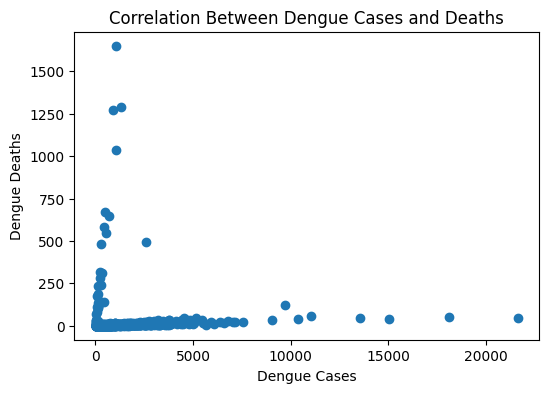

In [11]:
corr_value = dengue[['Dengue_Cases', 'Dengue_Deaths']].corr().iloc[0,1]

print(f"Correlation between dengue cases and dengue deaths: {corr_value:.4f}")

# Scatter plot to visualize relationship
plt.figure(figsize=(6,4))
plt.scatter(dengue['Dengue_Cases'], dengue['Dengue_Deaths'])
plt.xlabel("Dengue Cases")
plt.ylabel("Dengue Deaths")
plt.title("Correlation Between Dengue Cases and Deaths")
plt.show()

<h1>INSIGHT 9</h1>

The correlation between dengue cases and deaths is extremely weak (0.0383), indicating that higher case counts do not necessarily correspond to higher death counts in the dataset. This suggests other factors—such as healthcare access, reporting quality, or outbreak severity—may influence mortality more than case volume alone.

<hr>

<h1>INSIGHT 10</h1>

The plot shows that most high-death observations occur at relatively low case counts, while regions or months with very high case numbers often report low deaths. This pattern implies possible variations in outbreak management, demographics, or timing that affect fatality outcomes independently of case magnitude.

<hr>